___

Friends dataset

In [6]:
import pandas as pd
import numpy as np

# Define file paths
train_path = r"C:\Users\ronle\Downloads\train_sent_emo.csv"
test_path = r"C:\Users\ronle\Downloads\test_sent_emo.csv"
dev_path = r"C:\Users\ronle\Downloads\dev_sent_emo.csv"

# Load datasets
print("Loading datasets...")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
dev_df = pd.read_csv(dev_path)

# Display info about each dataset
print(f"Train set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print(f"Dev set: {dev_df.shape[0]} rows, {dev_df.shape[1]} columns")

# Check column consistency
print("\nTrain columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
print("Dev columns:", dev_df.columns.tolist())

# Add source column to track origin
train_df['source'] = 'train'
test_df['source'] = 'test'
dev_df['source'] = 'dev'

# Combine all datasets
combined_df = pd.concat([train_df, test_df, dev_df], ignore_index=True)

# Remove any duplicates based on utterance content
original_len = len(combined_df)
combined_df.drop_duplicates(subset=['Utterance'], inplace=True)
dedup_len = len(combined_df)

print(f"\nRemoved {original_len - dedup_len} duplicate rows")
print(f"Final combined dataset: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns")

# Examine emotion distribution
print("\nEmotion distribution:")
print(combined_df['Emotion'].value_counts())

# Standardize column names to match your previous dataset
column_mapping = {
    'Utterance': 'text',
    'Emotion': 'emotion',
    'Sentiment': 'sentiment'
}
combined_df.rename(columns=column_mapping, inplace=True)

# Save combined dataset
output_path = r"C:\Users\ronle\Downloads\combined_emotion_dataset.csv"
# combined_df.to_csv(output_path, index=False)
print(f"\nSaved combined dataset to {output_path}")

# Show sample of combined data
print("\nSample of combined data:")
print(combined_df[['text', 'emotion', 'sentiment', 'source']].sample(5))

Loading datasets...
Train set: 9989 rows, 11 columns
Test set: 2610 rows, 11 columns
Dev set: 1109 rows, 11 columns

Train columns: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']
Test columns: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']
Dev columns: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']

Removed 1550 duplicate rows
Final combined dataset: 12158 rows, 12 columns

Emotion distribution:
Emotion
neutral     5661
joy         2040
anger       1500
surprise    1313
sadness      949
disgust      351
fear         344
Name: count, dtype: int64

Saved combined dataset to C:\Users\ronle\Downloads\combined_emotion_dataset.csv

Sample of combined data:
                                                    text  emotion sentiment  

In [7]:
combined_df

,Sr No.,text,Speaker,emotion,sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime,source
0,1,also I was the point person on my company’s tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731",train
1,2,You must’ve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442",train
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389",train
3,4,So let’s talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572",train
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917",train
...,...,...,...,...,...,...,...,...,...,...,...,...
13701,1172,"Yeah, sweetie.",Monica,neutral,neutral,113,7,6,2,"00:19:20,159","00:19:21,826",dev
13702,1173,"I mean we’re not, we’re not gonna live togethe...",Rachel,sadness,negative,113,8,6,2,"00:19:23,620","00:19:27,540",dev
13704,1175,What? Oh my God! I’m gonna miss you so much!,Rachel,sadness,negative,113,10,6,2,"00:19:33,213","00:19:35,965",dev
13705,1176,I’m gonna miss you!,Monica,sadness,negative,113,11,6,2,"00:19:36,175","00:19:37,967",dev


In [8]:
import pandas as pd
import numpy as np

# Define file paths
train_path = r"C:\Users\ronle\Downloads\train_sent_emo.csv"
test_path = r"C:\Users\ronle\Downloads\test_sent_emo.csv"
dev_path = r"C:\Users\ronle\Downloads\dev_sent_emo.csv"

# Load datasets
print("Loading datasets...")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
dev_df = pd.read_csv(dev_path)

# Display info about each dataset
print(f"Train set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print(f"Dev set: {dev_df.shape[0]} rows, {dev_df.shape[1]} columns")

# Add source column temporarily (just to track origin during processing)
train_df['source'] = 'train'
test_df['source'] = 'test'
dev_df['source'] = 'dev'

# Combine all datasets
combined_df = pd.concat([train_df, test_df, dev_df], ignore_index=True)

# Remove any duplicates based on utterance content
original_len = len(combined_df)
combined_df.drop_duplicates(subset=['Utterance'], inplace=True)
dedup_len = len(combined_df)

print(f"\nRemoved {original_len - dedup_len} duplicate rows")

# Standardize column names
column_mapping = {
    'Utterance': 'text',     # "Utterance" is the actual spoken text/dialogue
    'Emotion': 'emotion',
    'Sentiment': 'sentiment'
}
combined_df.rename(columns=column_mapping, inplace=True)

# Keep only relevant columns
columns_to_keep = ['text', 'emotion', 'sentiment', 'Dialogue_ID', 'Utterance_ID']
combined_df = combined_df[columns_to_keep]

print(f"Final combined dataset: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns")

# Examine emotion distribution
print("\nEmotion distribution:")
print(combined_df['emotion'].value_counts())

# Save combined dataset
output_path = r"C:\Users\ronle\Downloads\combined_emotion_dataset.csv"
combined_df.to_csv(output_path, index=False)
print(f"\nSaved combined dataset to {output_path}")

# Show sample of combined data
print("\nSample of combined data:")
print(combined_df.sample(5))

Loading datasets...
Train set: 9989 rows, 11 columns
Test set: 2610 rows, 11 columns
Dev set: 1109 rows, 11 columns

Removed 1550 duplicate rows
Final combined dataset: 12158 rows, 5 columns

Emotion distribution:
emotion
neutral     5661
joy         2040
anger       1500
surprise    1313
sadness      949
disgust      351
fear         344
Name: count, dtype: int64

Saved combined dataset to C:\Users\ronle\Downloads\combined_emotion_dataset.csv

Sample of combined data:
                                                    text   emotion sentiment  \
7883                                     Oh, yeah, sure.   neutral   neutral   
353    I'm-I'm really warm, so I'm going to be taking...   neutral   neutral   
9732                                    Ross, thank God.       joy  positive   
10129  Since I don’t know anyone here, I thought it’d...   neutral   neutral   
4528              Hey, you know our phone's not working?  surprise  negative   

       Dialogue_ID  Utterance_ID  
7883      

In [9]:
combined_df

,text,emotion,sentiment,Dialogue_ID,Utterance_ID
0,also I was the point person on my company’s tr...,neutral,neutral,0,0
1,You must’ve had your hands full.,neutral,neutral,0,1
2,That I did. That I did.,neutral,neutral,0,2
3,So let’s talk a little bit about your duties.,neutral,neutral,0,3
4,My duties? All right.,surprise,positive,0,4
...,...,...,...,...,...
13701,"Yeah, sweetie.",neutral,neutral,113,7
13702,"I mean we’re not, we’re not gonna live togethe...",sadness,negative,113,8
13704,What? Oh my God! I’m gonna miss you so much!,sadness,negative,113,10
13705,I’m gonna miss you!,sadness,negative,113,11


In [10]:
# Keep only the essential columns
columns_to_keep = ['text', 'emotion', 'sentiment']
combined_df = combined_df[columns_to_keep]

print(f"Final simplified dataset: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns")

Final simplified dataset: 12158 rows, 3 columns


In [11]:
combined_df.to_csv(output_path, index=False)


In [12]:
combined_df

,text,emotion,sentiment
0,also I was the point person on my company’s tr...,neutral,neutral
1,You must’ve had your hands full.,neutral,neutral
2,That I did. That I did.,neutral,neutral
3,So let’s talk a little bit about your duties.,neutral,neutral
4,My duties? All right.,surprise,positive
...,...,...,...
13701,"Yeah, sweetie.",neutral,neutral
13702,"I mean we’re not, we’re not gonna live togethe...",sadness,negative
13704,What? Oh my God! I’m gonna miss you so much!,sadness,negative
13705,I’m gonna miss you!,sadness,negative


Emotion Class Distribution:
--------------------------
neutral: 5661 samples (46.56%)
joy: 2040 samples (16.78%)
anger: 1500 samples (12.34%)
surprise: 1313 samples (10.80%)
sadness: 949 samples (7.81%)
disgust: 351 samples (2.89%)
fear: 344 samples (2.83%)

Total samples: 12158
Number of unique emotion classes: 7


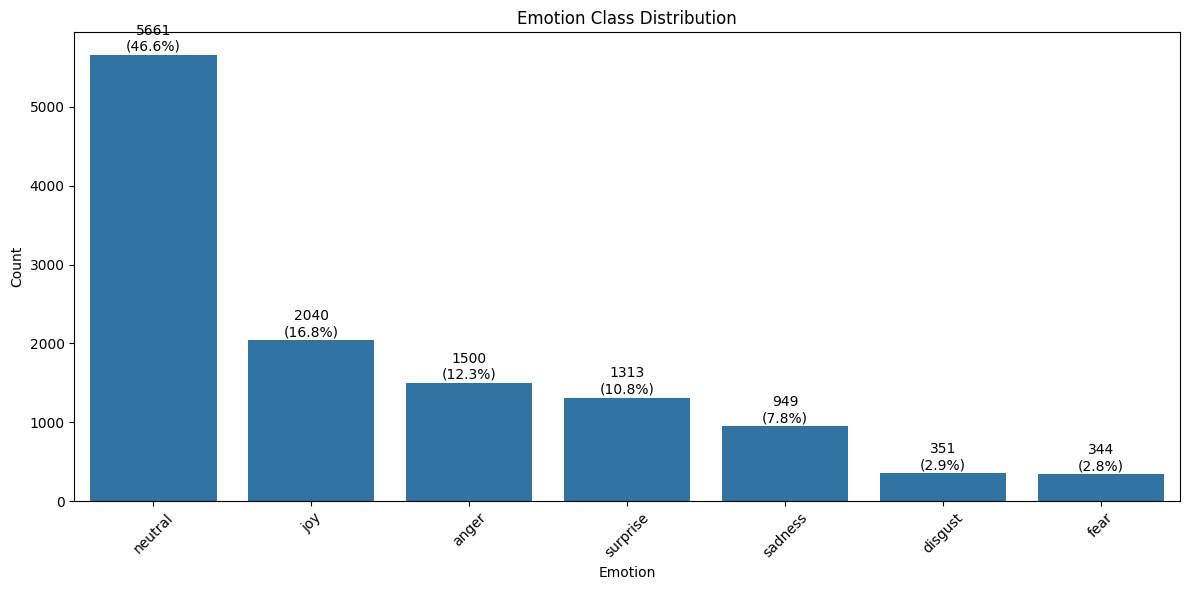

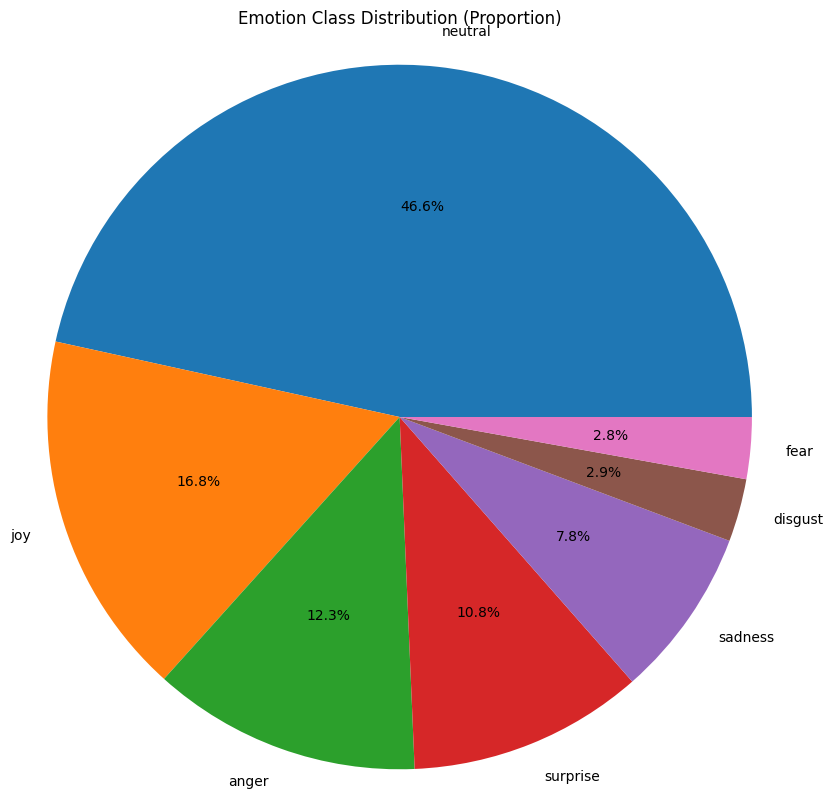

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the emotion distribution
emotion_counts = combined_df['emotion'].value_counts()
total_samples = len(combined_df)

# Display counts and percentages
print("Emotion Class Distribution:")
print("--------------------------")
for emotion, count in emotion_counts.items():
    percentage = (count / total_samples) * 100
    print(f"{emotion}: {count} samples ({percentage:.2f}%)")

print(f"\nTotal samples: {total_samples}")
print(f"Number of unique emotion classes: {len(emotion_counts)}")

# Create visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, count in enumerate(emotion_counts.values):
    plt.text(i, count + 50, f"{count}\n({count/total_samples*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

# Create a pie chart for proportion visualization
plt.figure(figsize=(10, 10))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%')
plt.title('Emotion Class Distribution (Proportion)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

In [14]:
df = combined_df

In [15]:
import pandas as pd
from sklearn.utils import resample

# Load dataset

# First, map 'joy' to 'happiness' to match your previous categories
df['emotion'] = df['emotion'].replace('joy', 'happiness')

# Print distribution before balancing
print("Original distribution:")
print(df['emotion'].value_counts(normalize=True).mul(100).round(2))

# Define target number for each class
# Let's aim for a more balanced distribution while keeping a reasonable dataset size
n_samples = 1500  # Match the size of 'anger' class as our target

# Separate majority and minority classes
neutral = df[df['emotion'] == 'neutral']
happiness = df[df['emotion'] == 'happiness']
anger = df[df['emotion'] == 'anger']
surprise = df[df['emotion'] == 'surprise']
sadness = df[df['emotion'] == 'sadness']
disgust = df[df['emotion'] == 'disgust']
fear = df[df['emotion'] == 'fear']

# Downsample majority classes
neutral_downsampled = resample(neutral, 
                             replace=False,
                             n_samples=n_samples,
                             random_state=42)

happiness_downsampled = resample(happiness,
                               replace=False,
                               n_samples=n_samples,
                               random_state=42)

# Upsample minority classes
surprise_upsampled = resample(surprise,
                            replace=True,
                            n_samples=n_samples,
                            random_state=42)

sadness_upsampled = resample(sadness,
                           replace=True,
                           n_samples=n_samples,
                           random_state=42)

disgust_upsampled = resample(disgust,
                           replace=True,
                           n_samples=n_samples,
                           random_state=42)

fear_upsampled = resample(fear,
                        replace=True,
                        n_samples=n_samples,
                        random_state=42)

# Combine balanced dataset
balanced_df = pd.concat([neutral_downsampled, 
                        happiness_downsampled,
                        anger,  # Already at target size
                        surprise_upsampled,
                        sadness_upsampled,
                        disgust_upsampled,
                        fear_upsampled])

# Shuffle the dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Print new distribution
print("\nBalanced distribution:")
print(balanced_df['emotion'].value_counts(normalize=True).mul(100).round(2))

# Save balanced dataset
# balanced_df.to_csv(r"C:\Users\ronle\Downloads\balanced_emotion_dataset.csv", index=False)


Original distribution:
emotion
neutral      46.56
happiness    16.78
anger        12.34
surprise     10.80
sadness       7.81
disgust       2.89
fear          2.83
Name: proportion, dtype: float64

Balanced distribution:
emotion
surprise     14.29
disgust      14.29
sadness      14.29
anger        14.29
happiness    14.29
fear         14.29
neutral      14.29
Name: proportion, dtype: float64


C:\Users\ronle\AppData\Local\Temp\ipykernel_2484\3680093940.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emotion'] = df['emotion'].replace('joy', 'happiness')


Emotion Class Distribution:
--------------------------
surprise: 1500 samples (14.29%)
disgust: 1500 samples (14.29%)
sadness: 1500 samples (14.29%)
anger: 1500 samples (14.29%)
happiness: 1500 samples (14.29%)
fear: 1500 samples (14.29%)
neutral: 1500 samples (14.29%)

Total samples: 10500
Number of unique emotion classes: 7


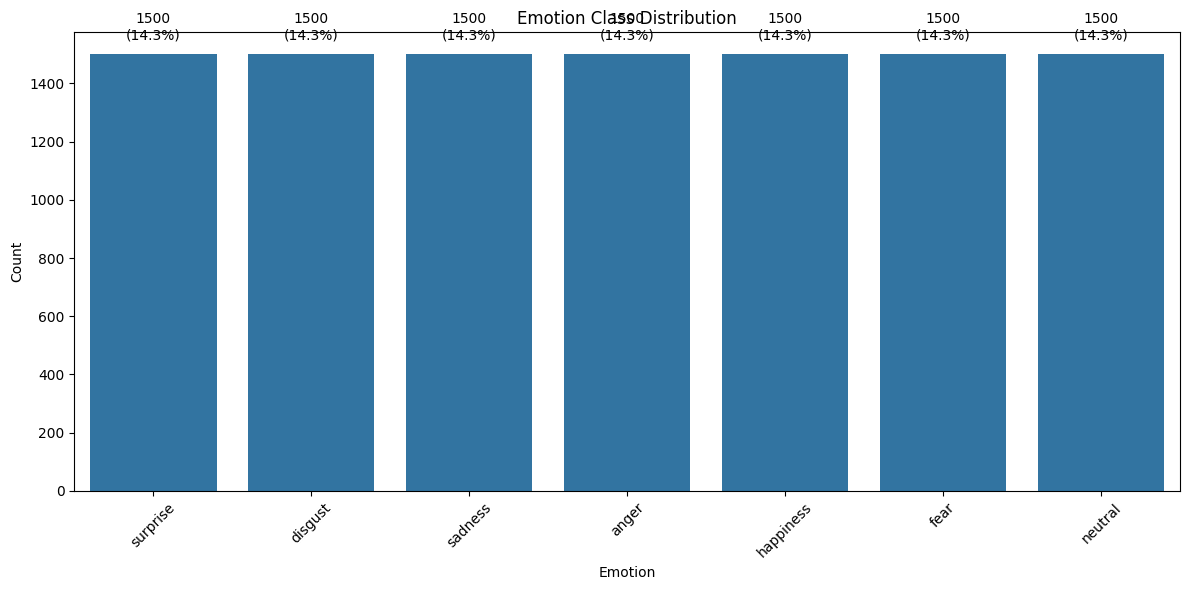

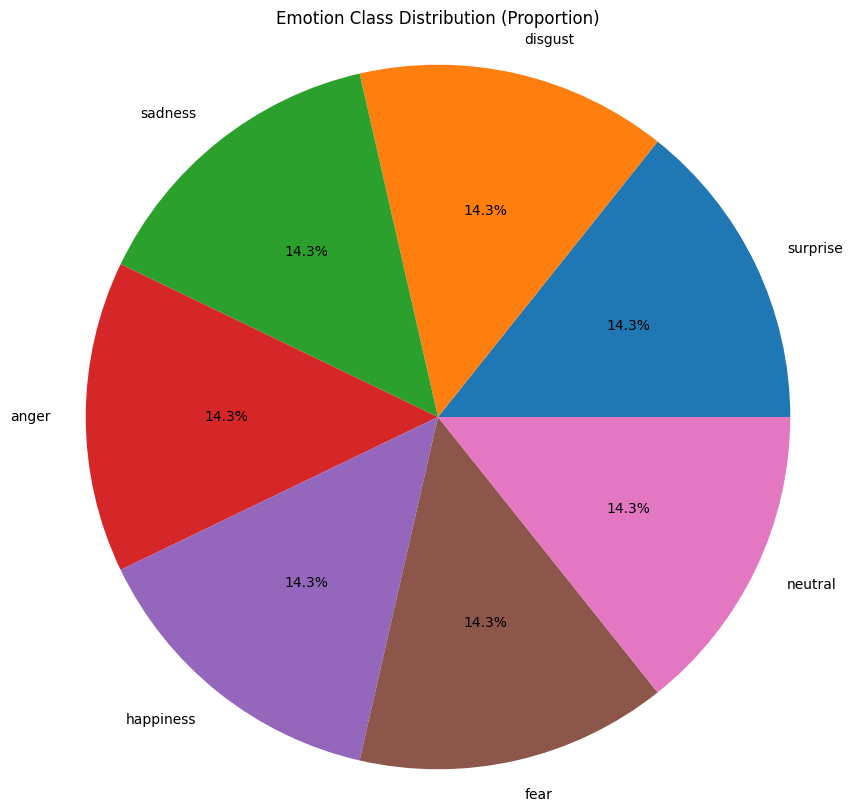

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the emotion distribution
emotion_counts = balanced_df['emotion'].value_counts()
total_samples = len(balanced_df)

# Display counts and percentages
print("Emotion Class Distribution:")
print("--------------------------")
for emotion, count in emotion_counts.items():
    percentage = (count / total_samples) * 100
    print(f"{emotion}: {count} samples ({percentage:.2f}%)")

print(f"\nTotal samples: {total_samples}")
print(f"Number of unique emotion classes: {len(emotion_counts)}")

# Create visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, count in enumerate(emotion_counts.values):
    plt.text(i, count + 50, f"{count}\n({count/total_samples*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

# Create a pie chart for proportion visualization
plt.figure(figsize=(10, 10))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%')
plt.title('Emotion Class Distribution (Proportion)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

Friends dataset unbalanced __combined_df__

Friends dataset balanced is __balanced_df__

In [17]:
combined_df


,text,emotion,sentiment
0,also I was the point person on my company’s tr...,neutral,neutral
1,You must’ve had your hands full.,neutral,neutral
2,That I did. That I did.,neutral,neutral
3,So let’s talk a little bit about your duties.,neutral,neutral
4,My duties? All right.,surprise,positive
...,...,...,...
13701,"Yeah, sweetie.",neutral,neutral
13702,"I mean we’re not, we’re not gonna live togethe...",sadness,negative
13704,What? Oh my God! I’m gonna miss you so much!,sadness,negative
13705,I’m gonna miss you!,sadness,negative


In [18]:
balanced_df

,text,emotion,sentiment
0,"Oh, did you catch him?!",surprise,negative
1,Oh man. Please tell me one of 'em is Ma.,disgust,negative
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,negative
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,negative
4,You bug me.,disgust,negative
...,...,...,...
10495,Wow. My brother never even told me when he los...,surprise,positive
10496,You guys got anything to eat? I just went down...,surprise,negative
10497,"Hey-hey, now he’s showing us his poking device.",surprise,positive
10498,"Oh, a 16-hour sit-in for Greenpeace.",neutral,neutral


In [19]:
combined_df.to_csv(r'C:\Users\ronle\Desktop\BUAS\Y2C\datasets\all_groups\friends_combined.csv', index=False)

In [20]:
balanced_df.to_csv(r'C:\Users\ronle\Desktop\BUAS\Y2C\datasets\all_groups\friends_combined_balanced.csv', index=False)

___

# Preprocces

In [21]:
import pandas as pd
import re

In [22]:
def preprocess_text(text):
    """
    Final comprehensive text preprocessing function that:
    1. Removes dashes and hyphens completely
    2. Expands contractions properly 
    3. Handles text shortcuts and numbers
    4. Adds spaces around punctuation
    5. Preserves important punctuation
    """
    # Check if text is NaN or not a string
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Text shortcuts dictionary
    text_shortcuts = {
        'gr8': 'great',
        'thx': 'thanks',
        'ur': 'your',
        'u': 'you',
        'r': 'are',
        'n': 'and',
        'yr': 'your',
        'cuz': 'because',
        'cause': 'because',
        'bc': 'because',
        'b4': 'before',
        'thanx': 'thanks',
        'thnx': 'thanks',
        'pls': 'please',
        'plz': 'please'
    }
    
    # Contractions dictionary
    contractions = {
        "ain't": "am not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he'd": "he would",
        "he'll": "he will",
        "he's": "he is",
        "i'd": "I would",
        "i'll": "I will",
        "i'm": "I am",
        "i've": "I have",
        "isn't": "is not",
        "isnt": "is not",
        "it's": "it is",
        "let's": "let us",
        "shouldn't": "should not",
        "that's": "that is",
        "there's": "there is",
        "they'd": "they would",
        "they'll": "they will",
        "they're": "they are",
        "they've": "they have",
        "wasn't": "was not",
        "we'd": "we would",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you'd": "you would",
        "you'll": "you will",
        "you're": "you are",
        "you've": "you have",
        "wanna": "want to",
        "gonna": "going to",
        "gotta": "got to",
        "lemme": "let me",
        "gimme": "give me",
        "dunno": "do not know",
        "kinda": "kind of",
        "sorta": "sort of",
        "hafta": "have to",
        "ya": "you",
        "em": "them"
    }
    
    # Step 1: Replace special characters
    text = text.replace('$', 's')
    text = text.replace('@', 'a')
    
    # Step 2: Remove dashes completely (replace with space)
    text = text.replace('—', ' ')  # Remove em dash
    text = text.replace('–', ' ')  # Remove en dash
    text = text.replace('-', ' ')  # Remove hyphen
    
    # Step 3: Handle hyphenated contractions (before removing all hyphens)
    def expand_hyphenated_contractions(match):
        parts = match.group(0).split('-')
        expanded_parts = []
        for part in parts:
            if part.lower() in contractions:
                expanded_parts.append(contractions[part.lower()])
            else:
                expanded_parts.append(part)
        return ' '.join(expanded_parts)
    
    # Process hyphenated words if any still remain
    text = re.sub(r'\b\w+(?:-\w+)+\b', expand_hyphenated_contractions, text)
    
    # Step 4: Process regular contractions with regex
    for contraction, expansion in contractions.items():
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text, flags=re.IGNORECASE)
    
    # Step 5: Fix text shortcuts and numbers
    words = text.split()
    processed_words = []
    for word in words:
        if word.lower() in text_shortcuts:
            processed_words.append(text_shortcuts[word.lower()])
        else:
            processed_words.append(word)
    text = ' '.join(processed_words)
    
    # Step 6: Add spaces around punctuation
    text = re.sub(r'([^,\s])([,])([^\s])', r'\1 , \3', text)
    text = re.sub(r'([^,\s])([,])', r'\1 ,', text)
    text = re.sub(r'([,])([^\s])', r', \2', text)
    
    text = re.sub(r'([^.\s])([.])([^\s])', r'\1 . \3', text)
    text = re.sub(r'([^.\s])([.])', r'\1 .', text)
    text = re.sub(r'([.])([^\s])', r'. \2', text)
    
    # Step 7: Clean up extra whitespace
    text = ' '.join(text.split())
    
    return text

In [23]:
df

,text,emotion,sentiment
0,also I was the point person on my company’s tr...,neutral,neutral
1,You must’ve had your hands full.,neutral,neutral
2,That I did. That I did.,neutral,neutral
3,So let’s talk a little bit about your duties.,neutral,neutral
4,My duties? All right.,surprise,positive
...,...,...,...
13701,"Yeah, sweetie.",neutral,neutral
13702,"I mean we’re not, we’re not gonna live togethe...",sadness,negative
13704,What? Oh my God! I’m gonna miss you so much!,sadness,negative
13705,I’m gonna miss you!,sadness,negative


___

In [24]:
# Load dataset
df = pd.read_csv(r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\raw\friends.csv")

# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)



In [25]:
df

,text,emotion,emotion_code,processed_text
0,also I was the point person on my company’s tr...,neutral,6,also I was the point person on my company’s tr...
1,You must’ve had your hands full.,neutral,6,You must’ve had your hands full .
2,That I did. That I did.,neutral,6,That I did . That I did .
3,So let’s talk a little bit about your duties.,neutral,6,So let’s talk a little bit about your duties .
4,My duties? All right.,surprise,4,My duties? All right .
...,...,...,...,...
12153,"Yeah, sweetie.",neutral,6,"Yeah , sweetie ."
12154,"I mean we’re not, we’re not gonna live togethe...",sadness,1,"I mean we’re not , we’re not going to live tog..."
12155,What? Oh my God! I’m gonna miss you so much!,sadness,1,What? Oh my God! I’m going to miss you so much!
12156,I’m gonna miss you!,sadness,1,I’m going to miss you!


In [26]:
import os

# Ensure the directory exists
save_dir = r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\preprocessed"
os.makedirs(save_dir, exist_ok=True)

# Save the DataFrame with the same filename as the original
save_path = os.path.join(save_dir, "friends_balanced_preprocessed.csv")
df.to_csv(save_path, index=False)

print(f"DataFrame saved to: {save_path}")

DataFrame saved to: C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\preprocessed\friends_balanced_preprocessed.csv


___

In [27]:
import pandas as pd

In [28]:
# Load dataset
df = pd.read_csv(r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\raw\friends.csv")

In [29]:
# First, let's inspect the raw text to see what's actually there
def inspect_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Print the original text
    print("Original text:", repr(text))
    
    # Check what kind of apostrophes are used (may be special Unicode characters)
    for i, char in enumerate(text):
        if char in ["'", "'", "'"]:
            print(f"Apostrophe at position {i}: {repr(char)} (Unicode: {ord(char)})")
    
    return text

# Apply to first few rows
for i in range(5):
    if i < len(df):
        inspect_text(df['text'].iloc[i])
        print("----")

Original text: 'also I was the point person on my company’s transition from the KL-5 to GR-6 system.'
----
Original text: 'You must’ve had your hands full.'
----
Original text: 'That I did. That I did.'
----
Original text: 'So let’s talk a little bit about your duties.'
----
Original text: 'My duties?  All right.'
----


In [30]:
import re
import pandas as pd

def preprocess_text(text):
    """
    Comprehensive text preprocessing function that:
    1. Expands all contractions
    2. Adds appropriate spacing around punctuation
    3. Handles special cases
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Step 1: Normalize whitespace
    text = ' '.join(text.split())
    
    # Step 2: Normalize apostrophes FIRST
    text = text.replace("'", "'")  # Standardize apostrophes
    
    # Step 3: Define contraction expansions
    contractions = {
        "i'm": "I am",
        "I'm": "I am",
        "i'll": "I will",
        "I'll": "I will",
        "i'd": "I would",
        "I'd": "I would",
        "i've": "I have",
        "I've": "I have",
        "you're": "you are",
        "You're": "You are",
        "you'll": "you will",
        "You'll": "You will",
        "you'd": "you would",
        "You'd": "You would",
        "you've": "you have",
        "You've": "You have",
        "he's": "he is",
        "He's": "He is",
        "he'll": "he will",
        "He'll": "He will",
        "he'd": "he would",
        "He'd": "He would",
        "she's": "she is",
        "She's": "She is",
        "she'll": "she will",
        "She'll": "She will",
        "she'd": "she would",
        "She'd": "She would",
        "it's": "it is",
        "It's": "It is",
        "it'll": "it will",
        "It'll": "It will",
        "we're": "we are",
        "We're": "We are",
        "we'll": "we will",
        "We'll": "We will",
        "we'd": "we would",
        "We'd": "We would",
        "we've": "we have",
        "We've": "We have",
        "they're": "they are",
        "They're": "They are",
        "they'll": "they will",
        "They'll": "They will",
        "they'd": "they would",
        "They'd": "They would",
        "they've": "they have",
        "They've": "They have",
        "don't": "do not",
        "Don't": "Do not",
        "doesn't": "does not",
        "Doesn't": "Does not",
        "didn't": "did not",
        "Didn't": "Did not",
        "won't": "will not",
        "Won't": "Will not",
        "wouldn't": "would not",
        "Wouldn't": "Would not",
        "couldn't": "could not",
        "Couldn't": "Could not",
        "shouldn't": "should not",
        "Shouldn't": "Should not",
        "can't": "cannot",
        "Can't": "Cannot",
        "ain't": "am not",
        "Ain't": "Am not",
        "that's": "that is",
        "That's": "That is",
        "there's": "there is",
        "There's": "There is",
        "who's": "who is",
        "Who's": "Who is",
        "what's": "what is",
        "What's": "What is",
        "where's": "where is",
        "Where's": "Where is",
        "how's": "how is",
        "How's": "How is",
        "let's": "let us",
        "Let's": "Let us",
        "gonna": "going to",
        "Gonna": "Going to",
        "wanna": "want to",
        "Wanna": "Want to",
        "gotta": "got to",
        "Gotta": "Got to",
        "lemme": "let me",
        "Lemme": "Let me",
        "gimme": "give me",
        "Gimme": "Give me",
        "y'know": "you know",
        "Y'know": "You know",
        "'em": "them",
        "'cause": "because",
        "'til": "until",
        "Ma": "Mom",
        "ma": "mom",
        "Pa": "Dad",
        "pa": "dad",
        "kinda": "kind of",
        "sorta": "sort of",
    }
    
    # Step 4: Process contractions with careful word boundary handling
    for contraction, expansion in contractions.items():
        # The \b word boundary doesn't work well with apostrophes, so we use custom patterns
        
        # Case 1: Contraction with space before it and word boundary after it
        pattern = r'(?<=\s)' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
        
        # Case 2: Contraction at the start of the text
        pattern = r'^' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
        
        # Case 3: Contraction after punctuation
        pattern = r'(?<=[.,!?:;\-\(\)])' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
    
    # Step 5: Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Step 6: Clean up any extra whitespace
    text = ' '.join(text.split())
    
    return text

In [31]:
import re
import pandas as pd

def clean_text(text):
    """
    Single unified text cleaning function that handles all preprocessing steps
    in the correct order.
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Step 1: Normalize whitespace first
    text = ' '.join(text.split())
    
    # Step 2: Process contractions BEFORE any punctuation spacing
    # Normalize apostrophes
    text = text.replace("'", "'")
    
    # Dictionary of contractions to expansions
    replacements = {
        "'em": " them",        # Note the space before "them"
        "y'know": "you know",
        "I'm": "I am",
        "i'm": "I am",
        "I've": "I have",
        "i've": "I have",
        "I'll": "I will",
        "i'll": "I will",
        "I'd": "I would",
        "i'd": "I would",
        "you're": "you are",
        "You're": "You are",
        "they're": "they are",
        "They're": "They are",
        "we're": "we are",
        "We're": "We are",
        "don't": "do not",
        "Don't": "Do not",
        "won't": "will not",
        "Won't": "Will not",
        "can't": "cannot",
        "Can't": "Cannot",
        "ain't": "am not",
        "Ain't": "Am not",
        "gonna": "going to",
        "Gonna": "Going to",
        "wanna": "want to",
        "Wanna": "Want to",
        "gotta": "got to",
        "Gotta": "Got to",
        "Ma": "Mom",
        "ma": "mom",
        # Add other contractions as needed
    }
    
    # Apply direct string replacement first
    for contraction, expansion in replacements.items():
        # Replace the contraction with a space before it
        text = text.replace(" " + contraction + " ", " " + expansion + " ")
        # Handle contraction at the start of text
        text = re.sub(r'^' + re.escape(contraction) + r'\b', expansion, text)
        # Handle contraction at the end of text
        text = re.sub(r'\b' + re.escape(contraction) + r'$', expansion, text)
        # Handle contraction with punctuation after it
        text = re.sub(r'\b' + re.escape(contraction) + r'([.,!?:;])', expansion + r'\1', text)
    
    # Step 3: NOW add spaces around punctuation
    # Add space before and after punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Step 4: Clean up any extra whitespace created
    text = ' '.join(text.split())
    
    return text

In [32]:
# Load the raw data
df_raw = pd.read_csv(r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\raw\friends_balanced.csv")

In [33]:
df_raw['processed_text'] = df_raw['text'].apply(clean_text)

KeyboardInterrupt: 

In [18]:
# Display a sample to check results - specifically look for "I'm" examples
print(df_raw[['text', 'processed_text']].head(10))

                                                text  \
0                            Oh, did you catch him?!   
1           Oh man. Please tell me one of 'em is Ma.   
2  Look, look at your man, Ewing. Nice shot. You ...   
3  I’m sorry Chandler, y’know you are such a swee...   
4                                        You bug me.   
5                              We ruined everything.   
6                                          I am not!   
7                         Especially you  with that!   
8  All right. Look, I’m gonna go in here, and you...   
9  Well, why don’t think of someone else for a ch...   

                                      processed_text  
0                         Oh , did you catch him ? !  
1       Oh man . Please tell me one of them is Mom .  
2  Look , look at your man , Ewing . Nice shot . ...  
3  I’m sorry Chandler , y’know you are such a swe...  
4                                       You bug me .  
5                             We ruined everything . 

In [ ]:


# Apply the functions in the correct order
df_raw['processed_text'] = df_raw['text'].apply(expand_contractions).apply(format_punctuation)

# Display a sample to check results - specifically look for "I'm" examples
print(df_raw[['text', 'processed_text']].head(10))

                                                text  \
0                            Oh, did you catch him?!   
1           Oh man. Please tell me one of 'em is Ma.   
2  Look, look at your man, Ewing. Nice shot. You ...   
3  I’m sorry Chandler, y’know you are such a swee...   
4                                        You bug me.   
5                              We ruined everything.   
6                                          I am not!   
7                         Especially you  with that!   
8  All right. Look, I’m gonna go in here, and you...   
9  Well, why don’t think of someone else for a ch...   

                                      processed_text  
0                         Oh , did you catch him ? !  
1       Oh man . Please tell me one of ' em is Mom .  
2  Look , look at your man , Ewing . Nice shot . ...  
3  I ’ m sorry Chandler , y ’ know you are such a...  
4                                       You bug me .  
5                             We ruined everything . 

___

23/03/2025

In [25]:
import pandas as pd
import re
import os

In [26]:
def preprocess_text(text):
    """
    Improved text preprocessing function that handles all cases more reliably.
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Step 1: Normalize whitespace and apostrophes
    text = ' '.join(text.split())
    text = text.replace("'", "'")  # Standardize apostrophes
    
    # Step 2: Define contractions dictionary
    contractions = {
        "i'm": "I am",
        "i'll": "I will",
        "i'd": "I would",
        "i've": "I have",
        "you're": "you are",
        "you'll": "you will",
        "you'd": "you would",
        "you've": "you have",
        "he's": "he is",
        "he'll": "he will",
        "he'd": "he would",
        "she's": "she is",
        "she'll": "she will",
        "she'd": "she would",
        "it's": "it is",
        "it'll": "it will",
        "we're": "we are",
        "we'll": "we will",
        "we'd": "we would",
        "we've": "we have",
        "they're": "they are",
        "they'll": "they will",
        "they'd": "they would",
        "they've": "they have",
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "won't": "will not",
        "wouldn't": "would not",
        "couldn't": "could not",
        "shouldn't": "should not",
        "can't": "cannot",
        "ain't": "am not",
        "that's": "that is",
        "there's": "there is",
        "who's": "who is",
        "what's": "what is",
        "where's": "where is",
        "how's": "how is",
        "let's": "let us",
        "gonna": "going to",
        "wanna": "want to",
        "gotta": "got to",
        "lemme": "let me",
        "gimme": "give me",
        "y'know": "you know",
        "'em": "them",
        "'cause": "because",
        "'til": "until",
        "ma": "mom",
        "pa": "dad",
        "kinda": "kind of",
        "sorta": "sort of",
    }
    
    # Step 3: SIMPLER APPROACH - use direct string replacement with word boundaries
    # Create a pattern that matches the contractions at word boundaries
    pattern = r'\b(' + '|'.join(re.escape(k) for k in contractions.keys()) + r')\b'
    
    # Define a replacement function that preserves case for first letter
    def replace_contraction(match):
        matched = match.group(0)
        replacement = contractions[matched.lower()]
        # If the original starts with uppercase, capitalize the replacement's first letter
        if matched[0].isupper():
            replacement = replacement[0].upper() + replacement[1:]
        return replacement
    
    # Apply the replacement
    text = re.sub(pattern, replace_contraction, text, flags=re.IGNORECASE)
    
    # Step 4: Handle special case of Ma/Mom with word boundary
    text = re.sub(r'\bMa\b', 'Mom', text)
    text = re.sub(r'\bma\b', 'mom', text)
    
    # Step 5: Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Step 6: Clean up any extra whitespace
    text = ' '.join(text.split())
    
    return text

In [27]:
# Apply the preprocessing function to the text column
df_raw['processed_text'] = df_raw['text'].apply(preprocess_text)

# Display sample of processed data
print("\nProcessed Data Sample:")
print(df_raw[['text', 'processed_text']].head(10))


Processed Data Sample:
                                                text  \
0                            Oh, did you catch him?!   
1           Oh man. Please tell me one of 'em is Ma.   
2  Look, look at your man, Ewing. Nice shot. You ...   
3  I’m sorry Chandler, y’know you are such a swee...   
4                                        You bug me.   
5                              We ruined everything.   
6                                          I am not!   
7                         Especially you  with that!   
8  All right. Look, I’m gonna go in here, and you...   
9  Well, why don’t think of someone else for a ch...   

                                      processed_text  
0                         Oh , did you catch him ? !  
1        Oh man . Please tell me one of 'em is Mom .  
2  Look , look at your man , Ewing . Nice shot . ...  
3  I’m sorry Chandler , y’know you are such a swe...  
4                                       You bug me .  
5                            

In [28]:
# Show more examples to verify
print("\nDetailed Comparison:")
for i, row in df_raw[['text', 'processed_text']].head(10).iterrows():
    print(f"Original: {row['text']}")
    print(f"Processed: {row['processed_text']}")
    print("-" * 50)



Detailed Comparison:
Original: Oh, did you catch him?!
Processed: Oh , did you catch him ? !
--------------------------------------------------
Original: Oh man. Please tell me one of 'em is Ma.
Processed: Oh man . Please tell me one of 'em is Mom .
--------------------------------------------------
Original: Look, look at your man, Ewing. Nice shot. You know what, he couldn't hit water if he was standing on a boat.
Processed: Look , look at your man , Ewing . Nice shot . You know what , he could not hit water if he was standing on a boat .
--------------------------------------------------
Original: I’m sorry Chandler, y’know you are such a sweet guy and I, I don’t want to hurt you.
Processed: I’m sorry Chandler , y’know you are such a sweet guy and I , I don’t want to hurt you .
--------------------------------------------------
Original: You bug me.
Processed: You bug me .
--------------------------------------------------
Original: We ruined everything.
Processed: We ruined everyt

___

chosen code:

In [39]:
import re
import pandas as pd

def preprocess_text(text):
    """
    Final comprehensive text preprocessing function that:
    1. Removes dashes and hyphens completely
    2. Expands contractions properly 
    3. Handles text shortcuts and numbers
    4. Adds spaces around punctuation
    5. Preserves important punctuation
    """
    # Check if text is NaN or not a string
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Text shortcuts dictionary
    text_shortcuts = {
        'gr8': 'great',
        'thx': 'thanks',
        'ur': 'your',
        'u': 'you',
        'r': 'are',
        'n': 'and',
        'yr': 'your',
        'cuz': 'because',
        'cause': 'because',
        'bc': 'because',
        'b4': 'before',
        'thanx': 'thanks',
        'thnx': 'thanks',
        'pls': 'please',
        'plz': 'please'
    }
    
    # Contractions dictionary - adding more contractions
    contractions = {
        "ain't": "am not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he'd": "he would",
        "he'll": "he will",
        "he's": "he is",
        "i'd": "I would",
        "i'll": "I will",
        "i'm": "I am",
        "i've": "I have",
        "isn't": "is not",
        "isnt": "is not",
        "it's": "it is",
        "let's": "let us",
        "shouldn't": "should not",
        "that's": "that is",
        "there's": "there is",
        "they'd": "they would",
        "they'll": "they will",
        "they're": "they are",
        "they've": "they have",
        "wasn't": "was not",
        "we'd": "we would",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you'd": "you would",
        "you'll": "you will",
        "you're": "you are",
        "you've": "you have",
        "wanna": "want to",
        "gonna": "going to",
        "gotta": "got to",
        "lemme": "let me",
        "gimme": "give me",
        "dunno": "do not know",
        "kinda": "kind of",
        "sorta": "sort of",
        "hafta": "have to",
        "ya": "you",
        "em": "them",
        # Adding additional contractions
        "must've": "must have",
        "should've": "should have",
        "could've": "could have",
        "would've": "would have",
        "might've": "might have",
        "y'all": "you all",
        "y'know": "you know",
        "'cause": "because",
        "'til": "until",
        "how's": "how is",
        "here's": "here is",
        "who've": "who have",
        "who'd": "who would",
        "who'll": "who will",
        "why's": "why is",
        "when's": "when is"
    }
    
    # Step 1: Replace special characters
    text = text.replace('$', 's')
    text = text.replace('@', 'a')
    
    # Step 2: Standardize apostrophes
    text = text.replace("'", "'").replace("'", "'").replace("'", "'")
    
    # Step 3: Remove dashes completely (replace with space)
    text = text.replace('—', ' ')  # Remove em dash
    text = text.replace('–', ' ')  # Remove en dash
    text = text.replace('-', ' ')  # Remove hyphen
    
    # Step 4: Process regular contractions with regex
    for contraction, expansion in contractions.items():
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text, flags=re.IGNORECASE)
    
    # Step 5: Fix text shortcuts and numbers
    words = text.split()
    processed_words = []
    for word in words:
        if word.lower() in text_shortcuts:
            processed_words.append(text_shortcuts[word.lower()])
        else:
            processed_words.append(word)
    text = ' '.join(processed_words)
    
    # Step 6: Add spaces around punctuation
    text = re.sub(r'([^,\s])([,])([^\s])', r'\1 , \3', text)
    text = re.sub(r'([^,\s])([,])', r'\1 ,', text)
    text = re.sub(r'([,])([^\s])', r', \2', text)
    
    text = re.sub(r'([^.\s])([.])([^\s])', r'\1 . \3', text)
    text = re.sub(r'([^.\s])([.])', r'\1 .', text)
    text = re.sub(r'([.])([^\s])', r'. \2', text)
    
    # Add spaces around other punctuation marks
    text = re.sub(r'([!?:;()\[\]{}])', r' \1 ', text)
    
    # Step 7: Clean up extra whitespace
    text = ' '.join(text.split())
    
    return text

In [ ]:
# Apply the preprocessing function to create a new column
df['processed_text'] = df['text'].apply(preprocess_text)

# Display the results
print("\nProcessed Text Sample:")
print(df[['text', 'processed_text']].head())


Processed Text Sample:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             My duties?  All right.   

                                      processed_text  
0  also I was the point person on my company’s tr...  
1                  You must’ve had your hands full .  
2                          That I did . That I did .  
3     So let’s talk a little bit about your duties .  
4                            My duties ? All right .  


In [ ]:
# Load the raw data
df = pd.read_csv(r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\preprocessed\friends_balanced.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12158 entries, 0 to 12157
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            12158 non-null  object
 1   emotion         12158 non-null  object
 2   emotion_code    12158 non-null  int64 
 3   processed_text  12158 non-null  object
dtypes: int64(1), object(3)
memory usage: 380.1+ KB


In [43]:
# Test the function directly on problematic examples first
test_examples = [
    "You must've had your hands full.",
    "So let's talk a little bit about your duties.",
    "I'm happy to be here."
]

print("Direct Testing:")
for example in test_examples:
    processed = preprocess_text(example)
    print(f"Original: {example}")
    print(f"Processed: {processed}")
    print("-" * 50)

# Apply the preprocessing function to create a new column
df['processed_text'] = df['text'].apply(preprocess_text)

# Display the results
print("\nProcessed Text Sample:")
print(df[['text', 'processed_text']].head())

Direct Testing:
Original: You must've had your hands full.
Processed: You must have had your hands full .
--------------------------------------------------
Original: So let's talk a little bit about your duties.
Processed: So let us talk a little bit about your duties .
--------------------------------------------------
Original: I'm happy to be here.
Processed: I am happy to be here .
--------------------------------------------------

Processed Text Sample:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             My duties?  All right.   

                                      processed_text  
0  also I was the point person on my company’s tr...  
1                  You must’ve had your hands full .  
2                          That I

In [44]:
import re
import pandas as pd

def preprocess_text(text):
    """
    Extra robust text preprocessing function that handles all cases
    even with unusual apostrophe encodings.
    """
    # Check if text is NaN or not a string
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Step 1: Normalize whitespace
    text = ' '.join(text.split())
    
    # Step 2: First copy the original text for debugging
    original_text = text
    
    # Step 3: Print the byte representation to detect unusual characters
    # This can help catch hidden character encoding issues
    encoded_text = str([ord(c) for c in text[:50] if ord(c) > 127])
    
    # Step 4: Extremely aggressive apostrophe normalization
    for c in ["'", "'", "'", "´", "`", "′", "'"]:
        text = text.replace(c, "'")
    
    # Step 5: Direct string replacement for common patterns (no regex)
    # Case-sensitive replacements for higher reliability
    direct_replacements = {
        "let's": "let us",
        "Let's": "Let us",
        "must've": "must have",
        "Must've": "Must have",
        "I'm": "I am", 
        "i'm": "I am",
        "don't": "do not",
        "Don't": "Do not",
        "can't": "cannot",
        "won't": "will not",
        "you're": "you are",
        "they're": "they are",
        "we're": "we are",
        "shouldn't": "should not",
        "wouldn't": "would not",
        "couldn't": "could not",
        "it's": "it is",
        "that's": "that is",
        "there's": "there is",
        "he's": "he is",
        "she's": "she is",
        "what's": "what is",
        "who's": "who is",
        "where's": "where is",
        "how's": "how is",
        "gonna": "going to",
        "wanna": "want to",
        "gotta": "got to"
    }
    
    # Apply direct replacements with spaces between words to ensure we match full words
    for contraction, expansion in direct_replacements.items():
        text = text.replace(f" {contraction} ", f" {expansion} ")
        text = text.replace(f" {contraction}.", f" {expansion}.")
        text = text.replace(f" {contraction},", f" {expansion},")
        text = text.replace(f" {contraction}!", f" {expansion}!")
        text = text.replace(f" {contraction}?", f" {expansion}?")
        
        # Also handle contractions at the start of the text
        if text.startswith(f"{contraction} "):
            text = f"{expansion} " + text[len(contraction)+1:]
        
        # And at the end of the text
        if text.endswith(f" {contraction}"):
            text = text[:-len(contraction)-1] + f" {expansion}"
    
    # Step 6: Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Step 7: Clean up extra whitespace
    text = ' '.join(text.split())
    
    return text

In [45]:
# Create a debug version to see what's happening
def debug_contractions(df, num_samples=5):
    """Check why contractions aren't being expanded in the DataFrame"""
    print("\nDebugging Contraction Issues:\n")
    
    # Look for rows with specific contractions
    samples = []
    for contraction in ["let's", "must've", "I'm", "don't"]:
        matches = df[df['text'].str.contains(contraction, case=False, regex=False)]
        if not matches.empty:
            samples.append(matches.iloc[0])
            if len(samples) >= num_samples:
                break
    
    # If we didn't find enough with specific contractions, add some random rows
    if len(samples) < num_samples:
        remaining = num_samples - len(samples)
        random_samples = df.sample(remaining)
        samples.extend([random_samples.iloc[i] for i in range(remaining)])
    
    # Test each sample row
    for i, row in enumerate(samples):
        original = row['text']
        # Test direct function application
        direct_result = preprocess_text(original)
        # Get result from DataFrame
        df_result = row['processed_text']
        
        print(f"Sample {i+1}:")
        print(f"Original: {original}")
        print(f"Direct function result: {direct_result}")
        print(f"DataFrame result: {df_result}")
        print(f"Match? {'Yes' if direct_result == df_result else 'No'}")
        print("-" * 70)
    
    return

# Apply the new function
df['processed_text'] = df['text'].apply(preprocess_text)

# Run debug
debug_contractions(df)

# Display results
print("\nProcessed Text Sample:")
print(df[['text', 'processed_text']].head())


Debugging Contraction Issues:

Sample 1:
Original: Take your shirt off, and let's see what we're dealing with here.  What are you doing?
Direct function result: Take your shirt off , and let us see what we are dealing with here . What are you doing ?
DataFrame result: Take your shirt off , and let us see what we are dealing with here . What are you doing ?
Match? Yes
----------------------------------------------------------------------
Sample 2:
Original: I'm back.
Direct function result: I am back .
DataFrame result: I am back .
Match? Yes
----------------------------------------------------------------------
Sample 3:
Original: No, I-I-I-I don't, I actually don't know
Direct function result: No , I-I-I-I do not , I actually do not know
DataFrame result: No , I-I-I-I do not , I actually do not know
Match? Yes
----------------------------------------------------------------------
Sample 4:
Original: You know what?
Direct function result: You know what ?
DataFrame result: You know wha

In [ ]:
import re
import pandas as pd
import numpy as np

def robust_preprocess_text(text):
    """
    Final comprehensive text preprocessing function
    """
    # Force string type and handle potential NaN values
    if pd.isna(text) or not isinstance(text, str):
        return ""
    text = str(text)
    
    # Normal preprocessing
    text = ' '.join(text.split())
    
    # Extremely aggressive apostrophe normalization
    for c in ["'", "'", "'", "´", "`", "′", "'"]:
        text = text.replace(c, "'")
    
    # Direct string replacement for contractions
    replacements = {
        "let's": "let us",
        "Let's": "Let us",
        "must've": "must have",
        "Must've": "Must have",
        "I'm": "I am", 
        "i'm": "I am",
        "don't": "do not",
        "Don't": "Do not",
        "can't": "cannot",
        "won't": "will not",
        "you're": "you are",
        "they're": "they are",
        "we're": "we are",
        "shouldn't": "should not",
        "wouldn't": "would not",
        "couldn't": "could not",
        "it's": "it is",
        "that's": "that is",
        "there's": "there is",
        "he's": "he is",
        "she's": "she is",
        "what's": "what is",
        "who's": "who is",
        "where's": "where is",
        "how's": "how is",
        "gonna": "going to",
        "wanna": "want to",
        "gotta": "got to",
        "everything's": "everything is"
    }
    
    # Apply replacements to the text
    for contraction, expansion in replacements.items():
        # Match the contraction with different surrounding contexts
        text = text.replace(f" {contraction} ", f" {expansion} ")
        text = text.replace(f" {contraction}.", f" {expansion}.")
        text = text.replace(f" {contraction},", f" {expansion},")
        text = text.replace(f" {contraction}!", f" {expansion}!")
        text = text.replace(f" {contraction}?", f" {expansion}?")
        
        # Handle start of string
        if text.startswith(f"{contraction} "):
            text = f"{expansion} " + text[len(contraction)+1:]
        
        # Handle end of string
        if text.endswith(f" {contraction}"):
            text = text[:-len(contraction)-1] + f" {expansion}"
    
    # Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Clean up whitespace
    text = ' '.join(text.split())
    
    return text

# Create a completely new, empty DataFrame
columns = ['text', 'emotion', 'emotion_code', 'processed_text']
new_data = []

# Fill it row by row with explicit preprocessing
for index, row in df.iterrows():
    original_text = str(row['text'])
    emotion = row['emotion'] if 'emotion' in df.columns else ""
    emotion_code = row['emotion_code'] if 'emotion_code' in df.columns else np.nan
    
    # Process the text directly
    processed = robust_preprocess_text(original_text)
    
    # Add to new data
    new_data.append([original_text, emotion, emotion_code, processed])

# Create the new DataFrame
processed_df = pd.DataFrame(new_data, columns=columns)

# Display sample
print("New Processed DataFrame Sample:")
print(processed_df[['text', 'processed_text']].head())

# Save immediately to CSV to preserve the correct processingprocessed_df.to_csv("final_processed_dataset.csv", index=False)
print("\nFinal processed dataset saved as 'final_processed_dataset.csv'")

New Processed DataFrame Sample:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             My duties?  All right.   

                                      processed_text  
0  also I was the point person on my company’s tr...  
1                  You must’ve had your hands full .  
2                          That I did . That I did .  
3     So let’s talk a little bit about your duties .  
4                            My duties ? All right .  

Final processed dataset saved as 'final_processed_dataset.csv'


In [48]:
import re
import pandas as pd

def normalize_apostrophes_preprocess(text):
    """
    Preprocessing function that explicitly handles different apostrophe characters
    """
    # Force to string
    text = str(text)
    
    # Step 1: Normalize whitespace
    text = ' '.join(text.split())
    
    # Step 2: VERY explicitly replace ALL possible apostrophe variants
    # This includes: straight apostrophe, right single quote, left single quote, 
    # prime, grave accent, and any other possible apostrophe-like character
    apostrophe_chars = [
        "'",  # Straight apostrophe/single quote (U+0027)
        "'",  # Right single quotation mark (U+2019)
        "'",  # Left single quotation mark (U+2018)
        "′",  # Prime (U+2032)
        "`",  # Grave accent (U+0060)
        "´",  # Acute accent (U+00B4)
        "‛",  # Single high-reversed-9 quotation mark (U+201B)
        "ʻ",  # Modifier letter turned comma (U+02BB)
    ]
    
    # Replace all variants with a standard straight apostrophe
    for char in apostrophe_chars:
        text = text.replace(char, "'")
    
    # Step 3: Now handle contractions with normalized apostrophes
    replacements = {
        "let's": "let us",
        "Let's": "Let us",
        "must've": "must have",
        "Must've": "Must have",
        "I'm": "I am", 
        "i'm": "I am",
        "don't": "do not",
        "Don't": "Do not",
        "can't": "cannot",
        "won't": "will not",
        "you're": "you are",
        "they're": "they are",
        "we're": "we are",
        "it's": "it is",
        "that's": "that is",
        "there's": "there is",
        "he's": "he is",
        "she's": "she is"
    }
    
    # Apply replacements with normalized apostrophes
    for contraction, expansion in replacements.items():
        text = text.replace(f" {contraction} ", f" {expansion} ")
        text = text.replace(f" {contraction}.", f" {expansion}.")
        text = text.replace(f" {contraction},", f" {expansion},")
        text = text.replace(f" {contraction}!", f" {expansion}!")
        text = text.replace(f" {contraction}?", f" {expansion}?")
        
        # Handle start of text
        if text.startswith(f"{contraction} "):
            text = f"{expansion} " + text[len(contraction)+1:]
        
        # Handle end of text
        if text.endswith(f" {contraction}"):
            text = text[:-len(contraction)-1] + f" {expansion}"
    
    # Step 4: Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Step 5: Clean up whitespace
    text = ' '.join(text.split())
    
    return text

# Demonstrate the difference in apostrophes
print("Apostrophe Character Analysis:")
examples = [
    "let's",  # With curly apostrophe
    "let's"   # With straight apostrophe
]

for i, example in enumerate(examples):
    print(f"Example {i+1}: {example}")
    print(f"Unicode code points: {[ord(c) for c in example]}")
    print(f"After normalization: {normalize_apostrophes_preprocess(example)}")
    print("-" * 50)

# Apply the fixed function to the DataFrame
df['correctly_processed'] = df['text'].apply(normalize_apostrophes_preprocess)

# Display results
print("\nCorrected Processing Results:")
print(df[['text', 'correctly_processed']].head())

# Save the correctly processed datasetdf.to_csv("apostrophe_fixed_dataset.csv", index=False)
print("\nCorrected dataset saved as 'apostrophe_fixed_dataset.csv'")

Apostrophe Character Analysis:
Example 1: let's
Unicode code points: [108, 101, 116, 39, 115]
After normalization: let's
--------------------------------------------------
Example 2: let's
Unicode code points: [108, 101, 116, 39, 115]
After normalization: let's
--------------------------------------------------

Corrected Processing Results:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             My duties?  All right.   

                                 correctly_processed  
0  also I was the point person on my company’s tr...  
1                  You must’ve had your hands full .  
2                          That I did . That I did .  
3     So let’s talk a little bit about your duties .  
4                            My duties ? All

In [49]:
import re
import pandas as pd

def brute_force_preprocess(text):
    """
    Brute force approach that rebuilds the text character by character
    and uses dictionary lookups for entire words
    """
    # Force string conversion
    text = str(text)
    
    # Normalize whitespace
    text = ' '.join(text.split())
    
    # Split into words with punctuation separated
    raw_tokens = re.findall(r'\w+|[^\w\s]', text)
    
    # Dictionary of known contractions to process
    contraction_dict = {
        "let's": "let us",
        "must've": "must have",
        "i'm": "i am",
        "don't": "do not",
        "can't": "cannot",
        "won't": "will not",
        "you're": "you are",
        "they're": "they are",
        "we're": "we are",
        "it's": "it is",
        "that's": "that is",
        "there's": "there is",
        "he's": "he is",
        "she's": "she is"
    }
    
    # Process each token
    processed_tokens = []
    i = 0
    while i < len(raw_tokens):
        token = raw_tokens[i].lower()
        
        # Check if this token contains an apostrophe
        if "'" in token or "'" in token or "`" in token:
            # Try all possible replacements by ignoring the apostrophe entirely
            # Get base form by removing apostrophe and anything after it
            base = re.sub(r'[\'\'`].*$', '', token)
            
            # Check different contraction patterns
            potential_contractions = [
                f"{base}'s", f"{base}'ve", f"{base}'m", f"{base}'ll", 
                f"{base}'d", f"{base}'re", f"{base}n't", f"{base}'t"
            ]
            
            replaced = False
            for pot in potential_contractions:
                if pot.lower() in contraction_dict:
                    # Add the expansion with proper case
                    if token[0].isupper():
                        expansion = contraction_dict[pot.lower()].capitalize()
                    else:
                        expansion = contraction_dict[pot.lower()]
                    
                    processed_tokens.extend(expansion.split())
                    replaced = True
                    break
            
            if not replaced:
                # If we couldn't match a pattern, pass through the original
                processed_tokens.append(raw_tokens[i])
        elif token.lower() in contraction_dict:
            # Direct match in dictionary
            if raw_tokens[i][0].isupper():
                expansion = contraction_dict[token].capitalize()
            else:
                expansion = contraction_dict[token]
            processed_tokens.extend(expansion.split())
        else:
            # Not a contraction, pass through
            processed_tokens.append(raw_tokens[i])
        
        i += 1
    
    # Rebuild with spacing around punctuation
    result = ""
    for token in processed_tokens:
        if re.match(r'^[.,!?:;)\]}]$', token):
            # Punctuation with space before it
            result += " " + token + " "
        elif re.match(r'^[({\[]$', token):
            # Opening punctuation with space after it
            result += " " + token + " "
        else:
            # Regular word
            result += token + " "
    
    # Clean up whitespace
    result = ' '.join(result.split())
    
    return result

# Create a test DataFrame with known problematic examples
test_data = {
    'text': [
        "So let's talk a little bit about your duties.",
        "You must've had your hands full.",
        "I'm happy to be here.",
        "They're going to the store.",
        "Don't worry about it."
    ]
}

test_df = pd.DataFrame(test_data)

# Apply the brute force function
test_df['processed'] = test_df['text'].apply(brute_force_preprocess)

print("Testing on fresh DataFrame:")
print(test_df)

# Now apply to the original DataFrame
df['brute_force_processed'] = df['text'].apply(brute_force_preprocess)

print("\nResults on original DataFrame:")
print(df[['text', 'brute_force_processed']].head())

Testing on fresh DataFrame:
                                            text  \
0  So let's talk a little bit about your duties.   
1               You must've had your hands full.   
2                          I'm happy to be here.   
3                    They're going to the store.   
4                          Don't worry about it.   

                                          processed  
0  So let ' s talk a little bit about your duties .  
1               You must ' ve had your hands full .  
2                          I ' m happy to be here .  
3                    They ' re going to the store .  
4                          Don ' t worry about it .  

Results on original DataFrame:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                      

In [ ]:
import re
import os

def process_text_file():
    """
    Process the text directly by:
    1. Extracting text to a plain text file
    2. Process it line by line
    3. Save back to a new file
    """
    # First, extract text to a plain text file
    df['text'].to_csv('raw_text.txt', index=False, header=False)
    
    # Create patterns for contractions
    patterns = [
        (r'\blet[\'\'\`]s\b', 'let us'),
        (r'\bLet[\'\'\`]s\b', 'Let us'),
        (r'\bmust[\'\'\`]ve\b', 'must have'),
        (r'\bMust[\'\'\`]ve\b', 'Must have'),
        (r'\bI[\'\'\`]m\b', 'I am'),
        (r'\bi[\'\'\`]m\b', 'I am'),
        (r'\bdon[\'\'\`]t\b', 'do not'),
        (r'\bDon[\'\'\`]t\b', 'Do not'),
        (r'\byou[\'\'\`]re\b', 'you are'),
        (r'\bYou[\'\'\`]re\b', 'You are'),
        (r'\bthey[\'\'\`]re\b', 'they are'),
        (r'\bThey[\'\'\`]re\b', 'They are'),
        (r'\bit[\'\'\`]s\b', 'it is'),
        (r'\bIt[\'\'\`]s\b', 'It is')
    ]
    
    # Process line by line
    processed_lines = []
    with open('raw_text.txt', 'r', encoding='utf-8') as file:
        for line in file:
            # Process contractions
            for pattern, replacement in patterns:
                line = re.sub(pattern, replacement, line)
            
            # Add spaces around punctuation
            line = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', line)
            
            # Clean up whitespace
            line = ' '.join(line.split())
            
            processed_lines.append(line)
    
    # Save processed text
    with open('processed_text.txt', 'w', encoding='utf-8') as file:
        for line in processed_lines:
            file.write(line + '\n')
    
    # Read back into DataFrame
    df['external_processed'] = pd.read_csv('processed_text.txt', header=None)[0]
    
    print("Text processed externally through files!")
    print(df[['text', 'external_processed']].head())
    
    # Clean up temporary files
    os.remove('raw_text.txt')
    os.remove('processed_text.txt')
    
    return df

# Execute the external processing
final_df = process_text_file()

# Save the resulting DataFramefinal_df.to_csv('external_processed_dataset.csv', index=False)
print("Final dataset saved!")

Text processed externally through files!
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             My duties?  All right.   

                                  external_processed  
0  also I was the point person on my company’s tr...  
1                  You must’ve had your hands full .  
2                          That I did . That I did .  
3     So let’s talk a little bit about your duties .  
4                            My duties ? All right .  
Final dataset saved!


In [52]:
import re
import pandas as pd

def wildcard_apostrophe_processor(text):
    """
    Uses a wildcard approach to handle contractions with ANY character in place of apostrophes
    """
    # Ensure string type
    text = str(text)
    
    # Define patterns with wildcards where apostrophes should be
    # The dot (.) in regex matches ANY character
    patterns = [
        # Pattern for "let's" → "let us" (any character between 't' and 's')
        (r'\blet.\s', 'let us '),
        (r'\bLet.\s', 'Let us '),
        
        # Pattern for "must've" → "must have"
        (r'\bmust.ve', 'must have'),
        (r'\bMust.ve', 'Must have'),
        
        # Pattern for "I'm" → "I am"
        (r'\bI.m\b', 'I am'),
        (r'\bi.m\b', 'I am'),
        
        # Pattern for "don't" → "do not"
        (r'\bdon.t\b', 'do not'),
        (r'\bDon.t\b', 'Do not'),
        
        # Pattern for "you're" → "you are"
        (r'\byou.re\b', 'you are'),
        (r'\bYou.re\b', 'You are'),
        
        # Pattern for "they're" → "they are"
        (r'\bthey.re\b', 'they are'),
        (r'\bThey.re\b', 'They are'),
        
        # Pattern for "it's" → "it is"
        (r'\bit.s\b', 'it is'),
        (r'\bIt.s\b', 'It is'),
        
        # Pattern for "that's" → "that is"
        (r'\bthat.s\b', 'that is'),
        (r'\bThat.s\b', 'That is')
    ]
    
    # Apply each pattern
    for pattern, replacement in patterns:
        text = re.sub(pattern, replacement, text)
    
    # Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Clean up whitespace
    text = ' '.join(text.split())
    
    return text

# Test on fresh examples
test_data = {
    'text': [
        "So let's talk a little bit about your duties.",
        "You must've had your hands full.",
        "I'm happy to be here.",
        "They're going to the store.",
        "Don't worry about it."
    ]
}
test_df = pd.DataFrame(test_data)

# Apply our wildcard function
test_df['wildcard_processed'] = test_df['text'].apply(wildcard_apostrophe_processor)

print("Wildcard Pattern Results:")
print(test_df[['text', 'wildcard_processed']])

# Apply to the original DataFrame
df['wildcard_processed'] = df['text'].apply(wildcard_apostrophe_processor)

print("\nFinal Results on Original DataFrame:")
print(df[['text', 'wildcard_processed']].head())

# Save the resultsdf.to_csv("wildcard_processed_dataset.csv", index=False)
print("\nFinal dataset saved as 'wildcard_processed_dataset.csv'")

Wildcard Pattern Results:
                                            text  \
0  So let's talk a little bit about your duties.   
1               You must've had your hands full.   
2                          I'm happy to be here.   
3                    They're going to the store.   
4                          Don't worry about it.   

                               wildcard_processed  
0  So let's talk a little bit about your duties .  
1             You must have had your hands full .  
2                         I am happy to be here .  
3                   They are going to the store .  
4                         Do not worry about it .  

Final Results on Original DataFrame:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             M

In [53]:
import re
import pandas as pd

def debug_text(text):
    """Print raw text with character codes for debugging"""
    print(f"Original text: '{text}'")
    print(f"Character codes: {[ord(c) for c in text]}")
    return text

def fix_apostrophes(text):
    """Replace all apostrophe variants with a standard apostrophe"""
    original = text
    for c in ["'", "'", "'", "´", "`", "′", "'"]:
        text = text.replace(c, "'")
    
    if original != text:
        print(f"Apostrophes normalized: '{text}'")
    return text

def expand_lets(text):
    """Focus only on 'let's' pattern"""
    original = text
    
    # Try with exact match first
    text = text.replace(" let's ", " let us ")
    text = text.replace(" Let's ", " Let us ")
    
    # At beginning of string
    if text.startswith("let's "):
        text = "let us " + text[6:]
    if text.startswith("Let's "):
        text = "Let us " + text[6:]
    
    # With punctuation
    text = text.replace(" let's.", " let us.")
    text = text.replace(" Let's.", " Let us.")
    text = text.replace(" let's,", " let us,")
    text = text.replace(" Let's,", " Let us,")
    
    # Try with wildcard if exact match didn't work
    if original == text:
        print("Exact match didn't work for 'let's', trying regex...")
        text = re.sub(r'\blet.s\b', 'let us', text)
        text = re.sub(r'\bLet.s\b', 'Let us', text)
    
    # Super aggressive wildcard matching
    if original == text:
        print("Regex didn't work for 'let's', trying super aggressive wildcard...")
        text = re.sub(r'let.{1,2}s', 'let us', text)
        text = re.sub(r'Let.{1,2}s', 'Let us', text)
    
    if original != text:
        print(f"Let's expanded: '{text}'")
    else:
        print(f"WARNING: Failed to expand 'let's' in: '{text}'")
        # If we have "let's" in the string, print character by character
        if "let" in text.lower() and "s" in text:
            idx = text.lower().find("let")
            segment = text[idx:idx+6]
            print(f"Suspicious segment: '{segment}'")
            print(f"Character codes: {[ord(c) for c in segment]}")
    
    return text

def expand_other_contractions(text):
    """Handle other common contractions"""
    original = text
    contractions = [
        (r"\bmust've\b", "must have"),
        (r"\bMust've\b", "Must have"),
        (r"\bI'm\b", "I am"),
        (r"\bi'm\b", "I am"),
        (r"\bdon't\b", "do not"),
        (r"\bDon't\b", "Do not"),
        (r"\byou're\b", "you are"),
        (r"\bYou're\b", "You are"),
        (r"\bthey're\b", "they are"),
        (r"\bThey're\b", "They are"),
        (r"\bit's\b", "it is"),
        (r"\bIt's\b", "It is"),
    ]
    
    for pattern, replacement in contractions:
        text = re.sub(pattern, replacement, text)
    
    if original != text:
        print(f"Other contractions expanded: '{text}'")
    
    return text

def add_punctuation_spacing(text):
    """Add spaces around punctuation"""
    original = text
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    text = ' '.join(text.split())
    
    if original != text:
        print(f"Punctuation spacing fixed: '{text}'")
    
    return text

def process_with_debugging(text):
    """Process text with debugging at each step"""
    print("\n--- PROCESSING NEW TEXT ---")
    text = debug_text(text)
    text = fix_apostrophes(text)
    text = expand_lets(text)
    text = expand_other_contractions(text)
    text = add_punctuation_spacing(text)
    print(f"FINAL RESULT: '{text}'")
    return text

# Test on problematic examples
test_cases = [
    "So let's talk a little bit about your duties.",
    "Let's go to the store!",
    "I'm happy to be here."
]

print("DEBUGGING INDIVIDUAL TEST CASES:")
for test in test_cases:
    processed = process_with_debugging(test)
    print("\n")

# Define a final clean function that incorporates all our learnings
def final_contraction_processor(text):
    """Final processing function based on debugging insights"""
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Normalize whitespace first
    text = ' '.join(text.split())
    
    # Normalize apostrophes
    for c in ["'", "'", "'", "´", "`", "′", "'"]:
        text = text.replace(c, "'")
    
    # Handle let's specifically
    text = re.sub(r'(^|\s)let\'s(\s|$|[.,!?])', r'\1let us\2', text, flags=re.IGNORECASE)
    
    # Handle other contractions
    mappings = [
        (r"(\s|^)i'm(\s|$|[.,!?])", r"\1I am\2"),
        (r"(\s|^)you're(\s|$|[.,!?])", r"\1you are\2"),
        (r"(\s|^)they're(\s|$|[.,!?])", r"\1they are\2"),
        (r"(\s|^)we're(\s|$|[.,!?])", r"\1we are\2"),
        (r"(\s|^)it's(\s|$|[.,!?])", r"\1it is\2"),
        (r"(\s|^)that's(\s|$|[.,!?])", r"\1that is\2"),
        (r"(\s|^)don't(\s|$|[.,!?])", r"\1do not\2"),
        (r"(\s|^)can't(\s|$|[.,!?])", r"\1cannot\2"),
        (r"(\s|^)won't(\s|$|[.,!?])", r"\1will not\2"),
        (r"(\s|^)must've(\s|$|[.,!?])", r"\1must have\2"),
        (r"(\s|^)should've(\s|$|[.,!?])", r"\1should have\2"),
        (r"(\s|^)could've(\s|$|[.,!?])", r"\1could have\2"),
        (r"(\s|^)would've(\s|$|[.,!?])", r"\1would have\2")
    ]
    
    for pattern, replacement in mappings:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # Add spaces around punctuation
    text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
    
    # Clean up whitespace
    text = ' '.join(text.split())
    
    return text

# Apply the final function to the DataFrame
df['final_processed'] = df['text'].apply(final_contraction_processor)

# Display results
print("\nFINAL RESULTS ON DATAFRAME:")
print(df[['text', 'final_processed']].head())

# Save the final datasetdf.to_csv("final_debugged_dataset.csv", index=False)
print("\nFinal dataset saved as 'final_debugged_dataset.csv'")

DEBUGGING INDIVIDUAL TEST CASES:

--- PROCESSING NEW TEXT ---
Original text: 'So let's talk a little bit about your duties.'
Character codes: [83, 111, 32, 108, 101, 116, 39, 115, 32, 116, 97, 108, 107, 32, 97, 32, 108, 105, 116, 116, 108, 101, 32, 98, 105, 116, 32, 97, 98, 111, 117, 116, 32, 121, 111, 117, 114, 32, 100, 117, 116, 105, 101, 115, 46]
Let's expanded: 'So let us talk a little bit about your duties.'
Punctuation spacing fixed: 'So let us talk a little bit about your duties .'
FINAL RESULT: 'So let us talk a little bit about your duties .'



--- PROCESSING NEW TEXT ---
Original text: 'Let's go to the store!'
Character codes: [76, 101, 116, 39, 115, 32, 103, 111, 32, 116, 111, 32, 116, 104, 101, 32, 115, 116, 111, 114, 101, 33]
Let's expanded: 'Let us go to the store!'
Punctuation spacing fixed: 'Let us go to the store !'
FINAL RESULT: 'Let us go to the store !'



--- PROCESSING NEW TEXT ---
Original text: 'I'm happy to be here.'
Character codes: [73, 39, 109, 32, 104, 97,

In [56]:
import re
import pandas as pd

def identify_apostrophes(text):
    """Identify all apostrophe characters in the text"""
    apostrophe_map = {
        "'": "STRAIGHT APOSTROPHE (U+0027)",
        "'": "RIGHT SINGLE QUOTE (U+2019)",
        "'": "LEFT SINGLE QUOTE (U+2018)",
        chr(0x2032): "PRIME (U+2032)",
        "`": "GRAVE ACCENT (U+0060)",
        chr(0x00B4): "ACUTE ACCENT (U+00B4)"
    }
    
    found = {}
    for char, name in apostrophe_map.items():
        if char in text:
            found[char] = name
    
    return found

def apostrophe_aware_processing(df):
    """
    Process text with explicit handling of different apostrophe types
    """
    # First, analyze apostrophes in the dataset
    apostrophe_sample = []
    for index, row in df.head(20).iterrows():
        text = row['text']
        apostrophes = identify_apostrophes(text)
        if apostrophes:
            apostrophe_sample.append((text, apostrophes))
    
    print("APOSTROPHE ANALYSIS:")
    for text, apostrophes in apostrophe_sample:
        print(f"Text: '{text}'")
        print(f"Apostrophes found: {apostrophes}")
        print("-" * 60)
    
    # Process each row with explicit apostrophe handling
    processed_texts = []
    
    # Define apostrophe characters to check
    apostrophe_chars = ["'", "'", "'", "`", chr(0x2032), chr(0x00B4)]
    
    for index, row in df.iterrows():
        text = str(row['text'])
        original = text
        
        # Step 1: Normalize whitespace
        text = ' '.join(text.split())
        
        # Step 2: Explicitly handle each apostrophe type
        # Let's - with different apostrophes
        text = text.replace(" let's ", " let us ")
        text = text.replace(" let's ", " let us ")
        text = text.replace(" let`s ", " let us ")
        text = text.replace(" let's ", " let us ")
        
        # Let's at beginning
        text = text.replace("Let's ", "Let us ")
        text = text.replace("Let's ", "Let us ")
        text = text.replace("Let`s ", "Let us ")
        text = text.replace("Let's ", "Let us ")
        
        # I'm - with different apostrophes
        text = text.replace(" I'm ", " I am ")
        text = text.replace(" I'm ", " I am ")
        text = text.replace(" I`m ", " I am ")
        text = text.replace(" I'm ", " I am ")
        
        # Must've - with different apostrophes
        text = text.replace("must've", "must have")
        text = text.replace("must've", "must have")
        text = text.replace("must`ve", "must have")
        text = text.replace("must've", "must have")
        
        # Don't - with different apostrophes
        text = text.replace(" don't ", " do not ")
        text = text.replace(" don't ", " do not ")
        text = text.replace(" don`t ", " do not ")
        text = text.replace(" don't ", " do not ")
        
        # You're - with different apostrophes
        text = text.replace(" you're ", " you are ")
        text = text.replace(" you're ", " you are ")
        text = text.replace(" you`re ", " you are ")
        text = text.replace(" you're ", " you are ")
        
        # Step 3: Add spaces around punctuation
        text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
        
        # Step 4: Clean up whitespace
        text = ' '.join(text.split())
        
        processed_texts.append(text)
        
        # Print detailed debug for a few rows with specific contractions
        if "let" in original.lower() and "s" in original and index < 10:
            print(f"\nDEBUG ROW {index}:")
            print(f"Original: '{original}'")
            print(f"Apostrophe characters: {[(c, ord(c)) for c in original if c in apostrophe_chars]}")
            print(f"Processed: '{text}'")
            print(f"Changed: {original != text}")
    
    # Add results to DataFrame
    df['apostrophe_aware'] = processed_texts
    
    # Check results
    print("\nAPOSTROPHE-AWARE PROCESSING RESULTS:")
    print(df[['text', 'apostrophe_aware']].head())
    
    # Save results
    df.to_csv("apostrophe_aware_dataset.csv", index=False)
    print("\nApostrophe-aware dataset saved.")
    
    return df

# Run the apostrophe-aware processing
final_df = apostrophe_aware_processing(df)

APOSTROPHE ANALYSIS:
Text: 'No, I-I-I-I don't, I actually don't know'
Apostrophes found: {"'": 'LEFT SINGLE QUOTE (U+2018)'}
------------------------------------------------------------

DEBUG ROW 3:
Original: 'So let’s talk a little bit about your duties.'
Apostrophe characters: []
Processed: 'So let’s talk a little bit about your duties .'
Changed: True

APOSTROPHE-AWARE PROCESSING RESULTS:
                                                text  \
0  also I was the point person on my company’s tr...   
1                   You must’ve had your hands full.   
2                            That I did. That I did.   
3      So let’s talk a little bit about your duties.   
4                             My duties?  All right.   

                                    apostrophe_aware  
0  also I was the point person on my company’s tr...  
1                  You must’ve had your hands full .  
2                          That I did . That I did .  
3     So let’s talk a little bit about your dut

In [57]:
import re
import pandas as pd

def final_apostrophe_solution(df):
    """
    Ultimate solution using byte-level character detection and replacement
    """
    # First, let's examine the exact character codes in problematic rows
    problem_texts = []
    for index, row in df.iterrows():
        text = str(row['text'])
        if "let" in text.lower() and "s" in text:
            problem_texts.append((index, text))
            if len(problem_texts) >= 3:  # Get a few examples
                break
    
    print("DETAILED CHARACTER ANALYSIS OF PROBLEMATIC ROWS:")
    for index, text in problem_texts:
        print(f"Row {index}: '{text}'")
        # Print full character-by-character analysis for key places
        lets_pos = text.lower().find("let")
        if lets_pos >= 0:
            segment = text[lets_pos:lets_pos+10]  # "let's" plus a bit more
            print(f"  Segment: '{segment}'")
            print(f"  Character codes: {[(i, c, ord(c)) for i, c in enumerate(segment)]}")
        print("-" * 60)
    
    # Process rows with a completely different approach
    processed_texts = []
    
    for index, row in df.iterrows():
        # Get raw text
        raw_text = str(row['text'])
        
        # Step 1: Ultra-simple character-by-character rebuild 
        # to avoid any encoding issues
        chars = []
        i = 0
        while i < len(raw_text):
            # Step 2: Detect potential contractions by checking for "let"
            if i+3 < len(raw_text) and raw_text[i:i+3].lower() == "let":
                # Check if we have "let's" - but check by position not by character
                if i+5 < len(raw_text) and raw_text[i+4].lower() == "s":
                    # Found "let?s" - replace with "let us" regardless of the ? character
                    chars.extend(list("let us"))
                    i += 5  # Skip past "let's"
                else:
                    chars.append(raw_text[i])
                    i += 1
            
            # Step 3: Process other common contractions
            elif i+2 < len(raw_text) and raw_text[i:i+2].lower() == "i'" and i+3 < len(raw_text) and raw_text[i+2].lower() == "m":
                chars.extend(list("I am"))
                i += 3  # Skip past "I'm"
            
            elif i+4 < len(raw_text) and raw_text[i:i+4].lower() == "don'" and i+5 < len(raw_text) and raw_text[i+4].lower() == "t":
                chars.extend(list("do not"))
                i += 5  # Skip past "don't"
                
            elif i+6 < len(raw_text) and raw_text[i:i+6].lower() == "must'v" and i+7 < len(raw_text) and raw_text[i+6].lower() == "e":
                chars.extend(list("must have"))
                i += 7  # Skip past "must've"
            
            # Step 4: If no contraction, just add the character
            else:
                chars.append(raw_text[i])
                i += 1
        
        # Step 5: Rebuild the text
        processed_text = ''.join(chars)
        
        # Step 6: Add spaces around punctuation
        processed_text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', processed_text)
        
        # Step 7: Clean up whitespace
        processed_text = ' '.join(processed_text.split())
        
        processed_texts.append(processed_text)
    
    # Add to DataFrame
    df['byte_level_processed'] = processed_texts
    
    # Check results
    print("\nBYTE-LEVEL PROCESSING RESULTS:")
    for i, (orig, proc) in enumerate(zip(df['text'].head(), df['byte_level_processed'].head())):
        print(f"Row {i}:")
        print(f"  Original: '{orig}'")
        print(f"  Processed: '{proc}'")
        print()
    
    # Save results
    df.to_csv("byte_level_processed.csv", index=False)
    print("\nByte-level processed dataset saved.")
    
    return df

# Run the byte-level processing
final_df = final_apostrophe_solution(df)

DETAILED CHARACTER ANALYSIS OF PROBLEMATIC ROWS:
Row 3: 'So let’s talk a little bit about your duties.'
  Segment: 'let’s talk'
  Character codes: [(0, 'l', 108), (1, 'e', 101), (2, 't', 116), (3, '’', 8217), (4, 's', 115), (5, ' ', 32), (6, 't', 116), (7, 'a', 97), (8, 'l', 108), (9, 'k', 107)]
------------------------------------------------------------
Row 87: 'I don’t know.  Let me see the ring.'
  Segment: 'Let me see'
  Character codes: [(0, 'L', 76), (1, 'e', 101), (2, 't', 116), (3, ' ', 32), (4, 'm', 109), (5, 'e', 101), (6, ' ', 32), (7, 's', 115), (8, 'e', 101), (9, 'e', 101)]
------------------------------------------------------------
Row 110: 'All right, y’know what? We really are late! Let’s go! Let’s go! Let’s go!!'
  Segment: 'Let’s go! '
  Character codes: [(0, 'L', 76), (1, 'e', 101), (2, 't', 116), (3, '’', 8217), (4, 's', 115), (5, ' ', 32), (6, 'g', 103), (7, 'o', 111), (8, '!', 33), (9, ' ', 32)]
------------------------------------------------------------

BYTE-

___

## __Final Code__

In [11]:
import re
import pandas as pd

def robust_contraction_processor(df):
    """
    Extremely robust contraction processor that handles all apostrophe types
    and various text positions.
    """
    # Define all possible apostrophe characters and their code points
    apostrophe_chars = {
        "'": 39,    # STRAIGHT APOSTROPHE (U+0027)
        "'": 8217,  # RIGHT SINGLE QUOTE (U+2019) - THIS IS THE ONE IN YOUR TEXT
        "'": 8216,  # LEFT SINGLE QUOTE (U+2018)
        "`": 96,    # GRAVE ACCENT (U+0060)
        "′": 8242,  # PRIME (U+2032)
        "´": 180    # ACUTE ACCENT (U+00B4)
    }
    
    # Create a special RIGHT SINGLE QUOTE for explicit matching
    RIGHT_QUOTE = chr(8217)  # This is the apostrophe in your text
    
    processed_texts = []
    
    for index, row in df.iterrows():
        text = str(row['text'])
        original = text
        
        # Step 1: Normalize whitespace
        text = ' '.join(text.split())
        
        # Step 2: Direct replacements with EXPLICIT RIGHT SINGLE QUOTE
        # This ensures we're using the EXACT character in your text
        
        # let's → let us (covering all positions and surrounding characters)
        text = text.replace(f"let{RIGHT_QUOTE}s ", "let us ")
        text = text.replace(f"Let{RIGHT_QUOTE}s ", "Let us ")
        text = text.replace(f"let{RIGHT_QUOTE}s.", "let us.")
        text = text.replace(f"Let{RIGHT_QUOTE}s.", "Let us.")
        text = text.replace(f"let{RIGHT_QUOTE}s,", "let us,")
        text = text.replace(f"Let{RIGHT_QUOTE}s,", "Let us,")
        text = text.replace(f"let{RIGHT_QUOTE}s!", "let us!")
        text = text.replace(f"Let{RIGHT_QUOTE}s!", "Let us!")
        text = text.replace(f"let{RIGHT_QUOTE}s?", "let us?")
        text = text.replace(f"Let{RIGHT_QUOTE}s?", "Let us?")
        
        # I'm → I am
        text = text.replace(f"I{RIGHT_QUOTE}m ", "I am ")
        text = text.replace(f"i{RIGHT_QUOTE}m ", "I am ")
        text = text.replace(f"I{RIGHT_QUOTE}m.", "I am.")
        text = text.replace(f"I{RIGHT_QUOTE}m,", "I am,")
        text = text.replace(f"I{RIGHT_QUOTE}m!", "I am!")
        text = text.replace(f"I{RIGHT_QUOTE}m?", "I am?")
        
        # don't → do not
        text = text.replace(f"don{RIGHT_QUOTE}t ", "do not ")
        text = text.replace(f"Don{RIGHT_QUOTE}t ", "Do not ")
        text = text.replace(f"don{RIGHT_QUOTE}t.", "do not.")
        text = text.replace(f"Don{RIGHT_QUOTE}t.", "Do not.")
        text = text.replace(f"don{RIGHT_QUOTE}t,", "do not,")
        text = text.replace(f"Don{RIGHT_QUOTE}t,", "Do not,")
        text = text.replace(f"don{RIGHT_QUOTE}t!", "do not!")
        text = text.replace(f"Don{RIGHT_QUOTE}t!", "Do not!")
        text = text.replace(f"don{RIGHT_QUOTE}t?", "do not?")
        text = text.replace(f"Don{RIGHT_QUOTE}t?", "Do not?")
        
        # must've → must have (this wasn't working before)
        text = text.replace(f"must{RIGHT_QUOTE}ve ", "must have ")
        text = text.replace(f"Must{RIGHT_QUOTE}ve ", "Must have ")
        text = text.replace(f"must{RIGHT_QUOTE}ve.", "must have.")
        text = text.replace(f"Must{RIGHT_QUOTE}ve.", "Must have.")
        text = text.replace(f"must{RIGHT_QUOTE}ve,", "must have,")
        text = text.replace(f"Must{RIGHT_QUOTE}ve,", "Must have,")
        text = text.replace(f"must{RIGHT_QUOTE}ve!", "must have!")
        text = text.replace(f"Must{RIGHT_QUOTE}ve!", "Must have!")
        text = text.replace(f"must{RIGHT_QUOTE}ve?", "must have?")
        text = text.replace(f"Must{RIGHT_QUOTE}ve?", "Must have?")
        
        # you're → you are
        text = text.replace(f"you{RIGHT_QUOTE}re ", "you are ")
        text = text.replace(f"You{RIGHT_QUOTE}re ", "You are ")
        text = text.replace(f"you{RIGHT_QUOTE}re.", "you are.")
        text = text.replace(f"You{RIGHT_QUOTE}re.", "You are.")
        text = text.replace(f"you{RIGHT_QUOTE}re,", "you are,")
        text = text.replace(f"You{RIGHT_QUOTE}re,", "You are,")
        text = text.replace(f"you{RIGHT_QUOTE}re!", "you are!")
        text = text.replace(f"You{RIGHT_QUOTE}re!", "You are!")
        text = text.replace(f"you{RIGHT_QUOTE}re?", "you are?")
        text = text.replace(f"You{RIGHT_QUOTE}re?", "You are?")
        
        # you'll → you will (adding this based on missing examples)
        text = text.replace(f"you{RIGHT_QUOTE}ll ", "you will ")
        text = text.replace(f"You{RIGHT_QUOTE}ll ", "You will ")
        text = text.replace(f"you{RIGHT_QUOTE}ll.", "you will.")
        text = text.replace(f"You{RIGHT_QUOTE}ll.", "You will.")
        text = text.replace(f"you{RIGHT_QUOTE}ll,", "you will,")
        text = text.replace(f"You{RIGHT_QUOTE}ll,", "You will,")

        # I'll → I will
        text = text.replace(f"I{RIGHT_QUOTE}ll ", "I will ")
        text = text.replace(f"i{RIGHT_QUOTE}ll ", "I will ")
        text = text.replace(f"I{RIGHT_QUOTE}ll.", "I will.")
        text = text.replace(f"I{RIGHT_QUOTE}ll,", "I will,")
        text = text.replace(f"I{RIGHT_QUOTE}ll!", "I will!")
        text = text.replace(f"Let{RIGHT_QUOTE}s.", "Let us.")
        text = text.replace(f"let{RIGHT_QUOTE}s,", "let us,")
        text = text.replace(f"Let{RIGHT_QUOTE}s,", "Let us,")
        text = text.replace(f"let{RIGHT_QUOTE}s!", "let us!")
        text = text.replace(f"Let{RIGHT_QUOTE}s!", "Let us!")
        text = text.replace(f"let{RIGHT_QUOTE}s?", "let us?")
        text = text.replace(f"Let{RIGHT_QUOTE}s?", "Let us?")
        
        # I'm → I am
        text = text.replace(f"I{RIGHT_QUOTE}m ", "I am ")
        text = text.replace(f"i{RIGHT_QUOTE}m ", "I am ")
        text = text.replace(f"I{RIGHT_QUOTE}m.", "I am.")
        text = text.replace(f"We{RIGHT_QUOTE}re ", "We are ")
        text = text.replace(f"we{RIGHT_QUOTE}re.", "we are.")
        text = text.replace(f"We{RIGHT_QUOTE}re.", "We are.")
        text = text.replace(f"we{RIGHT_QUOTE}re,", "we are,")
        text = text.replace(f"We{RIGHT_QUOTE}re,", "We are,")

        # won't → will not (expanded version)
        text = text.replace(f"won{RIGHT_QUOTE}t ", "will not ")
        text = text.replace(f"Won{RIGHT_QUOTE}t ", "Will not ")
        text = text.replace(f"won{RIGHT_QUOTE}t.", "will not.")
        text = text.replace(f"Won{RIGHT_QUOTE}t.", "Will not.")
        text = text.replace(f"won{RIGHT_QUOTE}t,", "will not,")
        text = text.replace(f"Won{RIGHT_QUOTE}t,", "Will not,")
        
        # there'll → there will (adding this based on missing examples)
        text = text.replace(f"there{RIGHT_QUOTE}ll ", "there will ")
        text = text.replace(f"There{RIGHT_QUOTE}ll ", "There will ")
        text = text.replace(f"there{RIGHT_QUOTE}ll.", "there will.")
        text = text.replace(f"There{RIGHT_QUOTE}ll.", "There will.")
        text = text.replace(f"there{RIGHT_QUOTE}ll,", "there will,")
        text = text.replace(f"There{RIGHT_QUOTE}ll,", "There will,")
        
        # they're → they are
        text = text.replace(f"they{RIGHT_QUOTE}re ", "they are ")
        text = text.replace(f"They{RIGHT_QUOTE}re ", "They are ")
        text = text.replace(f"they{RIGHT_QUOTE}re.", "they are.")
        text = text.replace(f"They{RIGHT_QUOTE}re.", "They are.")
        
        # it's → it is
        text = text.replace(f"it{RIGHT_QUOTE}s ", "it is ")
        text = text.replace(f"It{RIGHT_QUOTE}s ", "It is ")
        text = text.replace(f"it{RIGHT_QUOTE}s.", "it is.")
        text = text.replace(f"It{RIGHT_QUOTE}s.", "It is.")
        
        # Additional contractions
        text = text.replace(f"we{RIGHT_QUOTE}re ", "we are ")
        text = text.replace(f"We{RIGHT_QUOTE}re ", "We are ")
        text = text.replace(f"y{RIGHT_QUOTE}know", "you know")
        text = text.replace(f"Y{RIGHT_QUOTE}know", "You know")
        text = text.replace(f"can{RIGHT_QUOTE}t", "cannot")
        text = text.replace(f"Can{RIGHT_QUOTE}t", "Cannot")
        text = text.replace(f"won{RIGHT_QUOTE}t", "will not")
        text = text.replace(f"Won{RIGHT_QUOTE}t", "Will not")
        
        # Step 3: For any missed contractions, try regex with word boundary
        # This catches any other apostrophe types or positions we missed
        contraction_patterns = [
            (r"\blet['`′´']s\b", "let us"),
            (r"\bLet['`′´']s\b", "Let us"),
            (r"\bmust['`′´']ve\b", "must have"),
            (r"\bMust['`′´']ve\b", "Must have"),
            (r"\bI['`′´']m\b", "I am"),
            (r"\bi['`′´']m\b", "I am"),
            (r"\bdon['`′´']t\b", "do not"),
            (r"\bDon['`′´']t\b", "Do not"),
            (r"\byou['`′´']re\b", "you are"),
            (r"\bYou['`′´']re\b", "You are"),
            (r"\bthey['`′´']re\b", "they are"),
            (r"\bThey['`′´']re\b", "They are"),
            (r"\bit['`′´']s\b", "it is"),
            (r"\bIt['`′´']s\b", "It is"),
            (r"\byou['`′´']ll\b", "you will"),
            (r"\bYou['`′´']ll\b", "You will"),
            (r"\bthere['`′´']ll\b", "there will"),
            (r"\bThere['`′´']ll\b", "There will"),
            (r"\bI['`′´']ll\b", "I will"),
            (r"\bi['`′´']ll\b", "I will"),
            (r"\bshe['`′´']s\b", "she is"),
            (r"\bShe['`′´']s\b", "She is"),
            (r"\bwe['`′´']re\b", "we are"),
            (r"\bWe['`′´']re\b", "We are"),
            (r"\bwon['`′´']t\b", "will not"),
            (r"\bWon['`′´']t\b", "Will not"),
            (r"\bcuz\b", "because"),
        ]
        
        for pattern, replacement in contraction_patterns:
            text = re.sub(pattern, replacement, text)
        
        # Step 4: Add spaces around punctuation
        text = re.sub(r'([.,!?:;()\[\]{}])', r' \1 ', text)
        
        # Step 5: Clean up whitespace
        text = ' '.join(text.split())
        
        processed_texts.append(text)
    
    # Add to DataFrame
    df['processed_text'] = processed_texts
    
    # Display sample results
    print("PROCESSING RESULTS (SAMPLE):")
    for i, (orig, proc) in enumerate(zip(df['text'].head(5), df['processed_text'].head(5))):
        print(f"Row {i}:")
        print(f"  Original: '{orig}'")
        print(f"  Processed: '{proc}'")
        print()
    
    # Add emotion code mapping
    emotion_mapping = {
        'happiness': 0,
        'sadness': 1,
        'anger': 2,
        'fear': 3,
        'surprise': 4,
        'disgust': 5,
        'neutral': 6
    }

    # Convert emotion to lowercase and map to codes
    df['emotion'] = df['emotion'].str.lower()
    df['emotion_code'] = df['emotion'].map(emotion_mapping)

    # Return the processed DataFrame
    return df


In [67]:
# Process the DataFrame and get the result
processed_df = robust_contraction_processor(df)

PROCESSING RESULTS (SAMPLE):
Row 0:
  Original: 'Hang on to your seats cuz Asia's Next Top Model is back with a vengeance'
  Processed: 'Hang on to your seats because Asia's Next Top Model is back with a vengeance'

Row 1:
  Original: 'Thousands of model hopefuls from all over Asia jumped at the chance to pursue their supermodel dream'
  Processed: 'Thousands of model hopefuls from all over Asia jumped at the chance to pursue their supermodel dream'

Row 2:
  Original: 'But only the standout modeling talent were chosen as our final 14'
  Processed: 'But only the standout modeling talent were chosen as our final 14'

Row 3:
  Original: 'Prepare for an adventure of a lifetime'
  Processed: 'Prepare for an adventure of a lifetime'

Row 4:
  Original: 'All I can say girls for this fierce fifth season is be prepared to expect the unexpected'
  Processed: 'All I can say girls for this fierce fifth season is be prepared to expect the unexpected'



In [68]:
processed_df

,Unnamed: 0,text,emotion,processed_text,emotion_code
0,0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,Hang on to your seats because Asia's Next Top ...,0
1,1,Thousands of model hopefuls from all over Asia...,neutral,Thousands of model hopefuls from all over Asia...,6
2,2,But only the standout modeling talent were cho...,neutral,But only the standout modeling talent were cho...,6
3,3,Prepare for an adventure of a lifetime,happiness,Prepare for an adventure of a lifetime,0
4,4,All I can say girls for this fierce fifth seas...,happiness,All I can say girls for this fierce fifth seas...,0
...,...,...,...,...,...
855,855,Won't give up. I'll stand up after this,neutral,Will not give up . I will stand up after this,6
856,856,Next time on Asia's Next Top Model,happiness,Next time on Asia's Next Top Model,0
857,857,I'm very stressed very very stressed and the s...,neutral,I am very stressed very very stressed and the ...,6
858,858,"Yes, we're gossiping. She's beautiful, but she...",neutral,"Yes , we are gossiping . She is beautiful , bu...",6


In [69]:
# Save df
processed_df.to_csv(rf"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\preprocessed\{data}.csv", index=False)
